In [1]:
!wget -nc https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv

--2024-04-15 06:37:30--  https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5085081 (4.8M) [text/csv]
Saving to: ‘bbc_text_cls.csv’

bbc_text_cls.csv    100%[===================>]   4.85M  --.-KB/s    in 0.07s   

2024-04-15 06:37:31 (70.4 MB/s) - ‘bbc_text_cls.csv’ saved [5085081/5085081]



In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D, Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [3]:
df = pd.read_csv('bbc_text_cls.csv')

In [4]:
df.head()

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [5]:
df['targets'] = df['labels'].astype('category').cat.codes

In [6]:
# Number of classes

K = df['targets'].max() + 1
K

5

In [7]:
df_train, df_test = train_test_split(df, test_size = 0.2)

In [83]:
class_names = df_train.labels.unique()

In [84]:
class_names


array(['business', 'sport', 'politics', 'tech', 'entertainment'],
      dtype=object)

In [28]:
# Convert sentences to sequences

MAX_VOCAB_SIZE = 2000
tokenizer = Tokenizer(num_words =MAX_VOCAB_SIZE )
tokenizer.fit_on_texts(df_train['text'])
sequences_train = tokenizer.texts_to_sequences(df_train['text'])
sequences_test = tokenizer.texts_to_sequences(df_test['text'])


In [46]:
# get word -> integer mapping

word2idx = tokenizer.word_index
V = len(word2idx)
print("Found %s unique tokens."% V)

Found 29517 unique tokens.


In [47]:
# pad sequences so that we gwt a N*T matrix

data_train = pad_sequences(sequences_train)
print('Shape of data train tensor:', data_train.shape)

Shape of data train tensor: (1780, 3491)


In [48]:
# get sequences length

T = data_train.shape[1]

In [49]:
data_test = pad_sequences(sequences_test, maxlen =T)
print('shape of data test tensor:', data_test.shape)

shape of data test tensor: (445, 3491)


In [87]:
from keras.layers import Input, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense
from keras.models import Model

# Parameters
D = 50  # Embedding dimension

# Input layer
i = Input(shape=(T,))

# Embedding layer
x = Embedding(V + 1, D)(i)  # V+1 because index 0 is reserved for padding

# Convolutional layers
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)

# Dense output layer
x = Dense(K, activation='softmax')(x)  # Replace x with your last layer output

# Create model
model = Model(i, x)




In [88]:
from keras.optimizers import Adam


In [89]:
model.compile(
    loss = SparseCategoricalCrossentropy(from_logits = True),
    optimizer = Adam(learning_rate = 1e-3),
    metrics = ['accuracy']
)

In [90]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [91]:
print('Training Model')

r = model.fit(
    data_train,
    df_train['targets'],
    epochs=100,
    validation_data=(data_test, df_test['targets']),
    callbacks=[early_stopping]  # Include early stopping callback
)


Training Model
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5727: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


56/56 [==============================] - 7s 103ms/step - loss: 1.5962 - accuracy: 0.2534 - val_loss: 1.5886 - val_accuracy: 0.2067
Epoch 2/100
56/56 [==============================] - 4s 79ms/step - loss: 1.2958 - accuracy: 0.4315 - val_loss: 0.9044 - val_accuracy: 0.6449
Epoch 3/100
56/56 [==============================] - 4s 63ms/step - loss: 0.5011 - accuracy: 0.8287 - val_loss: 0.3200 - val_accuracy: 0.8876
Epoch 4/100
56/56 [==============================] - 2s 43ms/step - loss: 0.1143 - accuracy: 0.9725 - val_loss: 0.2113 - val_accuracy: 0.9326
Epoch 5/100
56/56 [==============================] - 3s 52ms/step - loss: 0.0273 - accuracy: 0.9944 - val_loss: 0.1644 - val_accuracy: 0.9461
Epoch 6/100
56/56 [==============================] - 2s 28ms/step - loss: 0.0067 - accuracy: 1.0000 - val_loss: 0.1491 - val_accuracy: 0.9438
Epoch 7/100
56/56 [==============================] - 3s 47ms/step - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.1567 - val_accuracy: 0.9506
Epoch 8/100
56/56

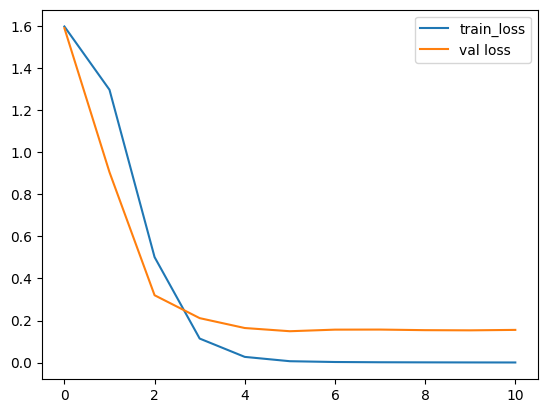

In [92]:
# Plot loss per iteration
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'val loss')
plt.legend()

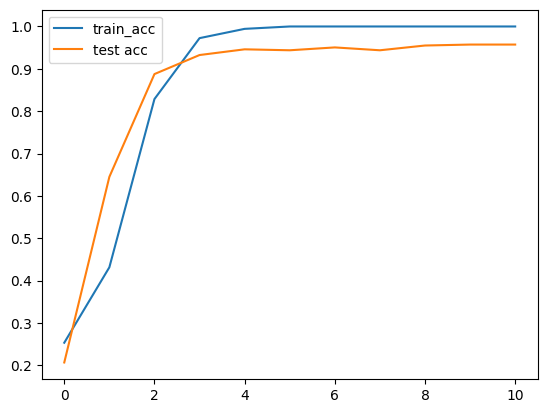

In [93]:
# Plot acc per iteration
plt.plot(r.history['accuracy'], label = 'train_acc')
plt.plot(r.history['val_accuracy'], label = 'test acc')
plt.legend()

In [94]:
train_loss, train_accuracy = model.evaluate(data_train, df_train['targets'])
test_loss, test_accuracy = model.evaluate(data_test, df_test['targets'])

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

14/14 [==============================] - 0s 5ms/step - loss: 0.1491 - accuracy: 0.9438
Train Accuracy: 1.0000
Test Accuracy: 0.9438


In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [96]:
y_train_pred = model.predict(data_train)
y_test_pred = model.predict(data_test)


14/14 [==============================] - 0s 3ms/step


In [98]:
# Accuracy
train_accuracy = accuracy_score(df_train['targets'], y_train_pred.argmax(axis=1))
test_accuracy = accuracy_score(df_test['targets'], y_test_pred.argmax(axis=1))

# Precision, Recall, F1-score
train_precision = precision_score(df_train['targets'], y_train_pred.argmax(axis=1), average='macro')
test_precision = precision_score(df_test['targets'], y_test_pred.argmax(axis=1), average='macro')

train_recall = recall_score(df_train['targets'], y_train_pred.argmax(axis=1), average='macro')
test_recall = recall_score(df_test['targets'], y_test_pred.argmax(axis=1), average='macro')

train_f1 = f1_score(df_train['targets'], y_train_pred.argmax(axis=1), average='macro')
test_f1 = f1_score(df_test['targets'], y_test_pred.argmax(axis=1), average='macro')

# AUC-ROC Score
train_auc = roc_auc_score(df_train['targets'], y_train_pred, multi_class='ovr')
test_auc = roc_auc_score(df_test['targets'], y_test_pred, multi_class='ovr')


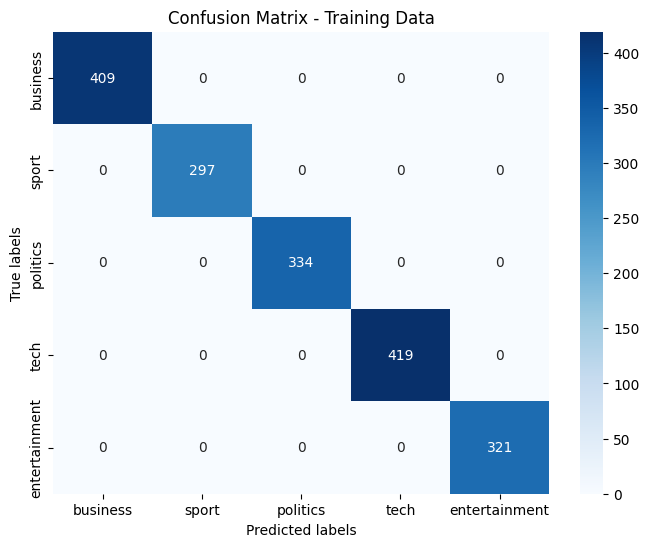

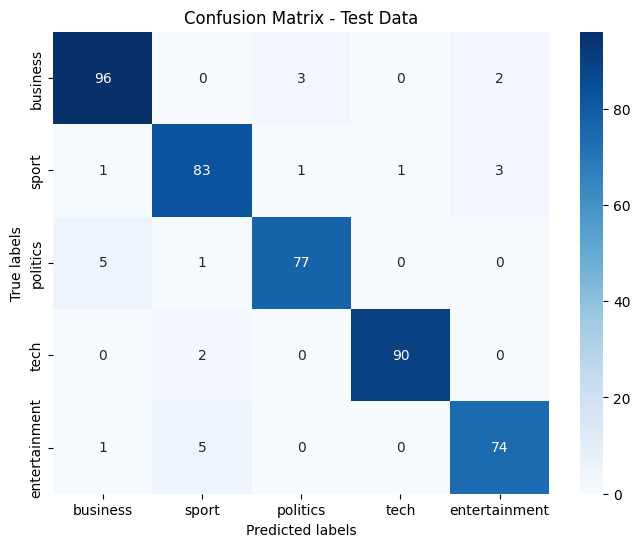

In [99]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.show()

# Define class labels
class_labels = ['business', 'sport', 'politics', 'tech', 'entertainment']

# Plot confusion matrix for training data
plot_confusion_matrix(df_train['targets'], y_train_pred.argmax(axis=1), labels=class_labels, title='Confusion Matrix - Training Data')

# Plot confusion matrix for test data
plot_confusion_matrix(df_test['targets'], y_test_pred.argmax(axis=1), labels=class_labels, title='Confusion Matrix - Test Data')


In [100]:
from sklearn.metrics import classification_report

# Calculate classification report
train_report = classification_report(df_train['targets'], y_train_pred.argmax(axis=1))
test_report = classification_report(df_test['targets'], y_test_pred.argmax(axis=1))

# Print evaluation metrics
print("Evaluation Metrics - Training Data:")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Train Precision: {train_precision:.4f}")
print(f"Train Recall: {train_recall:.4f}")
print(f"Train F1-score: {train_f1:.4f}")
print(f"Train AUC-ROC Score: {train_auc:.4f}")

print("\nEvaluation Metrics - Test Data:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test AUC-ROC Score: {test_auc:.4f}")

# Print classification report
print("\nClassification Report - Training Data:")
print(train_report)

print("\nClassification Report - Test Data:")
print(test_report)


Evaluation Metrics - Training Data:
Train Accuracy: 1.0000
Train Precision: 1.0000
Train Recall: 1.0000
Train F1-score: 1.0000
Train AUC-ROC Score: 1.0000

Evaluation Metrics - Test Data:
Test Accuracy: 0.9438
Test Precision: 0.9441
Test Recall: 0.9428
Test F1-score: 0.9434
Test AUC-ROC Score: 0.9961

Classification Report - Training Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       409
           1       1.00      1.00      1.00       297
           2       1.00      1.00      1.00       334
           3       1.00      1.00      1.00       419
           4       1.00      1.00      1.00       321

    accuracy                           1.00      1780
   macro avg       1.00      1.00      1.00      1780
weighted avg       1.00      1.00      1.00      1780


Classification Report - Test Data:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       101
           1       0.91 